In [1]:
!pip uninstall -y transformers huggingface-hub tokenizers
!pip install -q \
    "transformers==4.56.2" \
    "huggingface-hub==0.35.3" \
    "tokenizers==0.22.0" \
    "accelerate==1.6.0"


Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0
Found existing installation: huggingface_hub 1.11.0
Uninstalling huggingface_hub-1.11.0:
  Successfully uninstalled huggingface_hub-1.11.0
Found existing installation: tokenizers 0.22.2
Uninstalling tokenizers-0.22.2:
  Successfully uninstalled tokenizers-0.22.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 94.5 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 564.3/564.3 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 87.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.7/354.7 kB 26.1 MB/s eta 0:00:00


In [2]:
from datasets import load_dataset

ds = load_dataset(
    "HuggingFaceFW/fineweb-edu",
    "default",
    split="train",
    streaming=True,
)

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]

In [3]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
small_model_name = "Qwen/Qwen3-1.7B"
small_tokenizer = AutoTokenizer.from_pretrained(small_model_name)
large_model_name = "Qwen/Qwen3-4B"
large_tokenizer = AutoTokenizer.from_pretrained(large_model_name)
small_model = AutoModelForCausalLM.from_pretrained(small_model_name,torch_dtype="auto",device_map="auto")
large_model = AutoModelForCausalLM.from_pretrained(large_model_name,torch_dtype="auto",device_map="auto")


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

model-00001-of-00003.safetensors:   0%|          | 0.00/3.96G [00:00<?, ?B/s]

model-00002-of-00003.safetensors:   0%|          | 0.00/3.99G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/99.6M [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [4]:
sequences = []

for example in ds:
    ids = small_tokenizer(
        example["text"],
        add_special_tokens=False,
    )["input_ids"]

    if len(ids) >= 1024:
        sequences.append(ids[:1024])

    if len(sequences) == 500:
        break

In [5]:
print(small_model.config)

Qwen3Config {
  "architectures": [
    "Qwen3ForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "bos_token_id": 151643,
  "dtype": "bfloat16",
  "eos_token_id": 151645,
  "head_dim": 128,
  "hidden_act": "silu",
  "hidden_size": 2048,
  "initializer_range": 0.02,
  "intermediate_size": 6144,
  "layer_types": [
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention"
  ],
  "max_position_embeddings": 40960,
  "max_w

In [7]:
print("TARGET")
print("head_dim:", large_model.config.head_dim)
print("num_attention_heads:", large_model.config.num_attention_heads)
print("num_key_value_heads:", large_model.config.num_key_value_heads)
#print("rope_parameters:", large_model.config.rope_parameters)
print(large_model.model.rotary_emb)

TARGET
head_dim: 128
num_attention_heads: 32
num_key_value_heads: 8
Qwen3RotaryEmbedding()


In [8]:
print("head_dim:", small_model.config.head_dim)
print("num_attention_heads:", small_model.config.num_attention_heads)
print("num_key_value_heads:", small_model.config.num_key_value_heads)

print("rotary_scaling:", getattr(small_model.config, "rope_scaling", None))
#print("rope_parameters:", small_model.config.rope_parameters)

print("\nAttention module:")
print(small_model.model.layers[0].self_attn)

print("\nRoPE module:")
print(small_model.model.rotary_emb)

head_dim: 128
num_attention_heads: 16
num_key_value_heads: 8
rotary_scaling: None

Attention module:
Qwen3Attention(
  (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
  (k_proj): Linear(in_features=2048, out_features=1024, bias=False)
  (v_proj): Linear(in_features=2048, out_features=1024, bias=False)
  (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
  (q_norm): Qwen3RMSNorm((128,), eps=1e-06)
  (k_norm): Qwen3RMSNorm((128,), eps=1e-06)
)

RoPE module:
Qwen3RotaryEmbedding()


In [9]:
import inspect

print(inspect.signature(small_model.model.rotary_emb.forward))

(x, position_ids)


In [10]:
print(inspect.getsource(small_model.model.rotary_emb.forward))

    @torch.no_grad()
    @dynamic_rope_update  # power user: used with advanced RoPE types (e.g. dynamic rope)
    def forward(self, x, position_ids):
        inv_freq_expanded = self.inv_freq[None, :, None].float().expand(position_ids.shape[0], -1, 1).to(x.device)
        position_ids_expanded = position_ids[:, None, :].float()

        device_type = x.device.type if isinstance(x.device.type, str) and x.device.type != "mps" else "cpu"
        with torch.autocast(device_type=device_type, enabled=False):  # Force float32
            freqs = (inv_freq_expanded.float() @ position_ids_expanded.float()).transpose(1, 2)
            emb = torch.cat((freqs, freqs), dim=-1)
            cos = emb.cos() * self.attention_scaling
            sin = emb.sin() * self.attention_scaling

        return cos.to(dtype=x.dtype), sin.to(dtype=x.dtype)



In [11]:
import inspect

print(inspect.getsource(
    small_model.model.layers[0].self_attn.forward
))

    @deprecate_kwarg("past_key_value", new_name="past_key_values", version="4.58")
    def forward(
        self,
        hidden_states: torch.Tensor,
        position_embeddings: tuple[torch.Tensor, torch.Tensor],
        attention_mask: Optional[torch.Tensor],
        past_key_values: Optional[Cache] = None,
        cache_position: Optional[torch.LongTensor] = None,
        **kwargs: Unpack[FlashAttentionKwargs],
    ) -> tuple[torch.Tensor, Optional[torch.Tensor]]:
        input_shape = hidden_states.shape[:-1]
        hidden_shape = (*input_shape, -1, self.head_dim)

        query_states = self.q_norm(self.q_proj(hidden_states).view(hidden_shape)).transpose(1, 2)
        key_states = self.k_norm(self.k_proj(hidden_states).view(hidden_shape)).transpose(1, 2)
        value_states = self.v_proj(hidden_states).view(hidden_shape).transpose(1, 2)

        cos, sin = position_embeddings
        query_states, key_states = apply_rotary_pos_emb(query_states, key_states, cos, sin)

        if

In [12]:
sequences = []

for example in ds:
    ids = small_tokenizer(
        example["text"],
        add_special_tokens=False,
    )["input_ids"]

    if len(ids) >= 1024:
        sequences.append(ids[:1024])

    if len(sequences) == 500:
        break

In [13]:
print(len(sequences))

500


In [14]:
import torch

stride = 4
batch_size = 4

source_kv = []
target_kv = []

sequences = sequences[:100]

source_raw_k = {}
target_raw_k = {}


def make_k_hook(storage, layer_idx):
    def hook(module, inputs, output):
        storage[layer_idx] = output.detach().transpose(1, 2)  # -> (batch, n_kv_heads, seq, head_dim)
    return hook
source_hooks = []
target_hooks = []

for layer in range(28):
    hook = small_model.model.layers[layer].self_attn.k_norm.register_forward_hook(
        make_k_hook(source_raw_k, layer)
    )
    source_hooks.append(hook)

for layer in range(36):
    hook = large_model.model.layers[layer].self_attn.k_norm.register_forward_hook(
        make_k_hook(target_raw_k, layer)
    )
    target_hooks.append(hook)

for start in range(0, len(sequences), batch_size):
    print(start)

    batch_sequences = sequences[start:start + batch_size]

    input_ids = torch.tensor(
        batch_sequences,
        dtype=torch.long
    )

    source_raw_k.clear()
    target_raw_k.clear()

    with torch.no_grad():

        source_outputs = small_model(
            input_ids=input_ids.to(small_model.device),
            use_cache=True,
        )

        target_outputs = large_model(
            input_ids=input_ids.to(large_model.device),
            use_cache=True,
        )

    batch_size_actual = len(batch_sequences)

    for b in range(batch_size_actual):

        source_seq = []
        target_seq = []

        for layer in range(28):

            source_k = source_raw_k[layer][b, :, ::stride, :]
            source_v = source_outputs.past_key_values.layers[layer].values[
                b, :, ::stride, :
            ]

            source_seq.append((
                source_k.float().cpu(),
                source_v.float().cpu()
            ))

        for layer in range(36):

            target_k = target_raw_k[layer][b, :, ::stride, :]
            target_v = target_outputs.past_key_values.layers[layer].values[
                b, :, ::stride, :
            ]

            target_seq.append((
                target_k.float().cpu(),
                target_v.float().cpu()
            ))

        source_kv.append(source_seq)
        target_kv.append(target_seq)

    del source_outputs
    del target_outputs

for hook in source_hooks:
    hook.remove()

for hook in target_hooks:
    hook.remove()



0
4
8
12
16
20
24
28
32
36
40
44
48
52
56
60
64
68
72
76
80
84
88
92
96


In [15]:
import torch

num_source_layers = 28
num_target_layers = 36
num_heads = 8

r2_matrix = torch.zeros(
    num_source_layers,
    num_target_layers
)

for source_layer in range(num_source_layers):

    for target_layer in range(num_target_layers):

        head_r2 = []

        for head in range(num_heads):

            all_X = []
            all_Y = []

            for i in range(100):

                X = source_kv[i][source_layer][0][head]
                Y = target_kv[i][target_layer][0][head]

                all_X.append(X)
                all_Y.append(Y)

            X = torch.cat(all_X, dim=0)
            Y = torch.cat(all_Y, dim=0)

            X_aug = torch.cat(
                [
                    X,
                    torch.ones(X.shape[0], 1)
                ],
                dim=1
            )

            solution = torch.linalg.lstsq(
                X_aug,
                Y
            ).solution

            W_k = solution[:-1]
            b_k = solution[-1]

            Y_pred = X @ W_k + b_k

            ss_res = torch.sum(
                (Y - Y_pred) ** 2
            )

            
            ss_tot = ((Y - Y.mean(dim=0, keepdim=True)) ** 2).sum()

            r2 = 1 - ss_res / ss_tot

            head_r2.append(r2.item())

        mean_r2 = sum(head_r2) / len(head_r2)

        r2_matrix[source_layer, target_layer] = mean_r2

        

Source  0 → Target  0: 0.9944
Source  0 → Target  1: 0.9738
Source  0 → Target  2: 0.9291
Source  0 → Target  3: 0.9632
Source  0 → Target  4: 0.9475
Source  0 → Target  5: 0.9514
Source  0 → Target  6: 0.9493
Source  0 → Target  7: 0.9316
Source  0 → Target  8: 0.9551
Source  0 → Target  9: 0.8835
Source  0 → Target 10: 0.9752
Source  0 → Target 11: 0.9528
Source  0 → Target 12: 0.9692
Source  0 → Target 13: 0.8659
Source  0 → Target 14: 0.9551
Source  0 → Target 15: 0.8935
Source  0 → Target 16: 0.9015
Source  0 → Target 17: 0.9049
Source  0 → Target 18: 0.9226
Source  0 → Target 19: 0.9274
Source  0 → Target 20: 0.8992
Source  0 → Target 21: 0.9395
Source  0 → Target 22: 0.9421
Source  0 → Target 23: 0.9632
Source  0 → Target 24: 0.9240
Source  0 → Target 25: 0.9375
Source  0 → Target 26: 0.9157
Source  0 → Target 27: 0.9114
Source  0 → Target 28: 0.8953
Source  0 → Target 29: 0.9058
Source  0 → Target 30: 0.9512
Source  0 → Target 31: 0.9244
Source  0 → Target 32: 0.9160
Source  0 

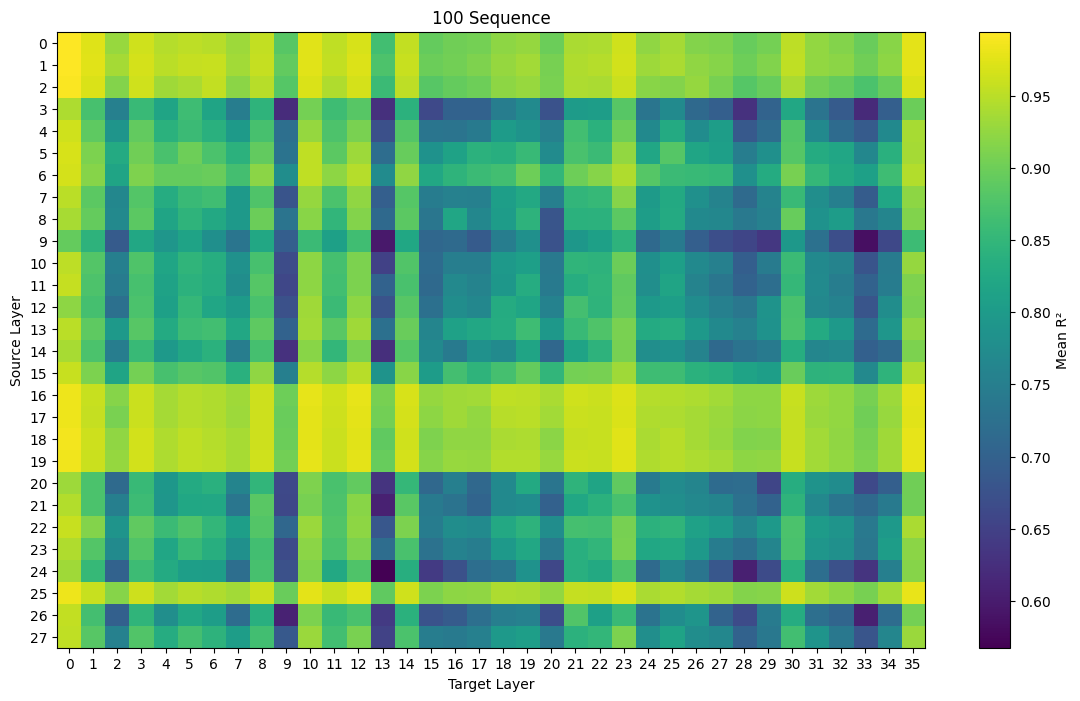

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))

plt.imshow(
    r2_matrix.numpy(),
    aspect="auto"
)

plt.colorbar(label="Mean R²")

plt.xlabel("Target Layer")
plt.ylabel("Source Layer")

plt.xticks(range(36))
plt.yticks(range(28))

plt.title("100 Sequence")

plt.show()

In [17]:
best_matches = {}

for target_layer in range(36):

    scores = r2_matrix[:, target_layer]

    best_source_layer = torch.argmax(scores).item()
    best_r2 = scores[best_source_layer].item()

    best_matches[target_layer] = {
        "source_layer": best_source_layer,
        "r2": best_r2
    }

for target_layer, result in best_matches.items():

    print(
        f"Target layer {target_layer:2d} "
        f"<- Source layer {result['source_layer']:2d} "
        f"R² = {result['r2']:.4f}"
    )

Target layer  0 <- Source layer  0 R² = 0.9944
Target layer  1 <- Source layer  1 R² = 0.9754
Target layer  2 <- Source layer  1 R² = 0.9361
Target layer  3 <- Source layer  1 R² = 0.9674
Target layer  4 <- Source layer  1 R² = 0.9505
Target layer  5 <- Source layer  1 R² = 0.9576
Target layer  6 <- Source layer  1 R² = 0.9579
Target layer  7 <- Source layer 18 R² = 0.9387
Target layer  8 <- Source layer 19 R² = 0.9638
Target layer  9 <- Source layer 19 R² = 0.9034
Target layer 10 <- Source layer 16 R² = 0.9787
Target layer 11 <- Source layer 16 R² = 0.9629
Target layer 12 <- Source layer 16 R² = 0.9789
Target layer 13 <- Source layer 16 R² = 0.9063
Target layer 14 <- Source layer 16 R² = 0.9689
Target layer 15 <- Source layer 16 R² = 0.9274
Target layer 16 <- Source layer 16 R² = 0.9342
Target layer 17 <- Source layer 16 R² = 0.9350
Target layer 18 <- Source layer 16 R² = 0.9539
Target layer 19 <- Source layer 16 R² = 0.9521
Target layer 20 <- Source layer 16 R² = 0.9403
Target layer 

In [18]:
import torch

source_layer = 0
target_layer = 25

head_r2_matrix = torch.zeros(8, 8)

for source_head in range(8):

    for target_head in range(8):

        all_X = []
        all_Y = []

        for i in range(100):

            X = source_kv[i][source_layer][0][source_head]
            Y = target_kv[i][target_layer][0][target_head]

            all_X.append(X)
            all_Y.append(Y)

        X = torch.cat(all_X, dim=0).float()
        Y = torch.cat(all_Y, dim=0).float()

        X_aug = torch.cat(
            [X, torch.ones(X.shape[0], 1)],
            dim=1
        )

        solution = torch.linalg.lstsq(X_aug, Y).solution

        W = solution[:-1]
        b = solution[-1]

        Y_pred = X @ W + b

        ss_res = ((Y - Y_pred) ** 2).sum()
        ss_tot = ((Y - Y.mean(dim=0, keepdim=True)) ** 2).sum()
        r2 = 1 - ss_res / ss_tot

        head_r2_matrix[source_head, target_head] = r2.item()

print(head_r2_matrix)

tensor([[0.9998, 0.9377, 0.9185, 0.9062, 0.8925, 0.8904, 0.8971, 0.8906],
        [0.9996, 0.9310, 0.9142, 0.8973, 0.8914, 0.8922, 0.8968, 0.8881],
        [0.9998, 0.9228, 0.9380, 0.9101, 0.9001, 0.8960, 0.8982, 0.8856],
        [0.9997, 0.9124, 0.9138, 0.9250, 0.9019, 0.9007, 0.9030, 0.8929],
        [0.9997, 0.9183, 0.9123, 0.9065, 0.9198, 0.9089, 0.9034, 0.8893],
        [0.9999, 0.9164, 0.9084, 0.9044, 0.9016, 0.9348, 0.9113, 0.8910],
        [0.9997, 0.9194, 0.9098, 0.8981, 0.8889, 0.9098, 0.9277, 0.9021],
        [0.9997, 0.9138, 0.9072, 0.9030, 0.8915, 0.8966, 0.9124, 0.9239]])


In [19]:
for target_head in range(8):

    scores = head_r2_matrix[:, target_head]

    best_source_head = torch.argmax(scores).item()
    best_r2 = scores[best_source_head].item()

    print(
        f"Target head {target_head} "
        f"<- Source head {best_source_head} "
        f"R² = {best_r2:.4f}"
    )

Target head 0 <- Source head 5 R² = 0.9999
Target head 1 <- Source head 0 R² = 0.9377
Target head 2 <- Source head 2 R² = 0.9380
Target head 3 <- Source head 3 R² = 0.9250
Target head 4 <- Source head 4 R² = 0.9198
Target head 5 <- Source head 5 R² = 0.9348
Target head 6 <- Source head 6 R² = 0.9277
Target head 7 <- Source head 7 R² = 0.9239


In [20]:
import torch

source_layer = 0
target_layer = 25

source_head = 1
target_head = 3

alpha = 0.1

all_X = []
all_Y = []

for i in range(50):

    X = source_kv[i][source_layer][0][source_head]
    Y = target_kv[i][target_layer][0][target_head]

    all_X.append(X)
    all_Y.append(Y)

X = torch.cat(all_X, dim=0).float()
Y = torch.cat(all_Y, dim=0).float()

X_aug = torch.cat(
    [X, torch.ones(X.shape[0], 1)],
    dim=1
)

n_features = X_aug.shape[1]

I = torch.eye(n_features)

I[-1, -1] = 0

W_full = torch.linalg.solve(
    X_aug.T @ X_aug + alpha * I,
    X_aug.T @ Y
)

W = W_full[:-1]
b = W_full[-1]

Y_pred = X @ W + b

print("W shape:", W.shape)
print("b shape:", b.shape)

W shape: torch.Size([128, 128])
b shape: torch.Size([128])
